# Proyek Analisis Data: [Bike-sharing-dataset.zip]
- **Nama:** [Meyrica Dianiken Cintami]
- **Email:** [meyricadianikencintami8@gmail.com]
- **ID Dicoding:** [CDCC115D6X1800]

## Menentukan Pertanyaan Bisnis

1.   Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?
2.   Pada jam berapa dan hari apa jumlah penyewaan sepeda paling tinggi?

## Import Semua Packages/Library yang Digunakan

In [23]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
from google.colab import files

**Penjelasan Singkat :**
* Pandas ini digunakan untuk membaca tabel, mengolah tabel, dan memanipulasi kolom dengan mudah.
* numpy in digunakan untuk perhitungan numerik dan operasi matematika.
* matplotlib.pyplot ini digunakan untuk membuat grafik dasar.
* seaborn ini digunakan untuk membuat visualisasi data yang lebih menarik.
* sns.set(style='whitegrid') ini untuk mengatur tampilan grafik agar lebih rapih dengan grid.
* download file yang sudah di olah

## Data Wrangling

### Gathering Data

In [24]:
day_df = pd.read_csv('day.csv') #membaca data
hour_df = pd.read_csv('hour.csv')

#menampilkan 5 data teratas
day_df.head()
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
* Dengan fungsi (pd.read.df) data berhasil dibaca dengan baik dan siap digunakan untuk analisis.
* Dari 5 data awal, kita bisa melihat gambaran isi tiap variabel. Misalnya, kolom holiday berisi nilai 1 (iya) dan 0 (tidak), serta kolom dteday memiliki format tanggal (tahun-bulan-hari) yang memudahkan proses pembersihan data.


### Assessing Data

In [25]:
print("1. Informasi Struktur dan Tipe Data:") # Baca informasi dan tipe data
print('informasi data harian')
day_df.info()
print('informasi data per-jam')
hour_df.info()
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("\n2. Pengecekan Data Missing Value:") # Cek adanya Missing Value
print("\nMissing Values Dataset Harian:")
print(day_df.isnull().sum())
print("\nMissing Values Dataset Per-Jam:")
print(hour_df.isnull().sum())
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("\n3. Pengecekan Duplikasi Data:") # Cek duplikasi
print("\nJumlah Duplikasi Dataset Harian:")
print(day_df.duplicated().sum())
print("\nJumlah Duplikasi Dataset Per-Jam:")
print(hour_df.duplicated().sum())
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("\n4. Ringkasan Statistik Data Numerik:") # Statistik deskriptif
print("\nStatistik Dataset Harian:")
display(day_df.describe())
print("\nStatistik Dataset Per-Jam:")
display(hour_df.describe())

1. Informasi Struktur dan Tipe Data:
informasi data harian
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
informasi data per-jam
<class 'pan

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000



Statistik Dataset Per-Jam:


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ditemukan missing value, jadi datanya sudah lengkap dan bisa langsung dipakai untuk analisis.
- Tidak ada data duplikat di kedua dataset, jadi datanya cukup bersih dan tidak ada pengulangan yang bisa bikin hasil jadi bias.
- kolom *dteday* masih berupa object, jadi perlu diubah ke datetime supaya lebih gampang dipakai untuk analisis waktu.
- Terlihat kalau beberapa variabel seperti suhu, kelembapan, dan kecepatan angin sudah dalam bentuk normalisasi (0–1), jadi perlu diperhatikan saat membaca nilainya.
- Nilai pada kolom cnt cukup bervariasi, yang berarti jumlah penyewaan sepeda bisa berubah-ubah tergantung kondisi tertentu.

### Cleaning Data

In [26]:
print("1. Mengubah tipe data kolom tanggal") # Mengubah tipe data kolom tanggal
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
print("Tipe data dteday (Day):", day_df['dteday'].dtype)
print("Tipe data dteday (Hour):", hour_df['dteday'].dtype)
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("2. Drop kolom yang nggak kepakai") # Drop kolom yang nggak kepakai
day_df.drop(columns=['instant'], inplace=True)
hour_df.drop(columns=['instant'], inplace=True)
print("Columns Day:", day_df.columns)
print("Columns Hour:", hour_df.columns)

1. Mengubah tipe data kolom tanggal
Tipe data dteday (Day): datetime64[ns]
Tipe data dteday (Hour): datetime64[ns]
------------------------------------------------------------
2. Drop kolom yang nggak kepakai
Columns Day: Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt'],
      dtype='object')
Columns Hour: Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


**Insight:**
- Kolom dteday sudah diubah ke format datetime, jadi lebih gampang dipakai untuk analisis yang berkaitan dengan waktu.
- Kolom instant dihapus karena tidak terlalu berpengaruh dalam analisis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [27]:
# Menampilkan 5 baris pertama dari DataFrame yang sudah dibersihkan
print("Data Setelah Cleaning Day:")
display(day_df.head())
print("\nData Setelah Cleaning Hour:")
display(hour_df.head())
print("-" * 100) # Garis pemisah biar output terlihat lebih rapih

# 1. Memeriksa kembali struktur data dan tipe data
print("\n---1. Informasi Struktur dan Tipe Data ---")
day_df.info()
hour_df.info()
print("-" * 100) # Garis pemisah biar output terlihat lebih rapih

# 2. Cuaca terhadap Jumlah Penyewaan
print("\n---2. Korelasi antara cuaca dan jumlah penyewaan: ---")
print(day_df[['temp','hum','windspeed','cnt']].corr())
print("-" * 100) # Garis pemisah biar output terlihat lebih rapih

# 3. Jam Paling Ramai
print("\n---3. Rata-rata penyewaan sepeda per jam: ---")
avg_hour = hour_df.groupby('hr')['cnt'].mean()
print(avg_hour)
print("-" * 100) # Garis pemisah biar output terlihat lebih rapih

#4. Hari Paling Ramai
print("\n---4. Rata-rata penyewaan sepeda per hari :---")
avg_day = hour_df.groupby('weekday')['cnt'].mean()
print(avg_day)

Data Setelah Cleaning Day:


,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Data Setelah Cleaning Hour:


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


----------------------------------------------------------------------------------------------------

---1. Informasi Struktur dan Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      731 non-null    datetime64[ns]
 1   season      731 non-null    int64         
 2   yr          731 non-null    int64         
 3   mnth        731 non-null    int64         
 4   holiday     731 non-null    int64         
 5   weekday     731 non-null    int64         
 6   workingday  731 non-null    int64         
 7   weathersit  731 non-null    int64         
 8   temp        731 non-null    float64       
 9   atemp       731 non-null    float64       
 10  hum         731 non-null    float64       
 11  windspeed   731 non-null    float64       
 12  casual      731 non-null    int64         
 13  registered  731 non-null 

**Insight:**
- Suhu memiliki hubungan positif dengan jumlah penyewaan sepeda, di mana semakin tinggi suhu, jumlah penyewaan cenderung meningkat, meskipun masih dipengaruhi faktor lain.
- Kondisi cuaca juga berpengaruh, di mana cuaca cerah memiliki jumlah penyewaan tertinggi, sedangkan saat cuaca memburuk, jumlah penyewaan menurun.
- Penyewaan sepeda paling rendah terjadi pada dini hari, lalu meningkat pada pagi hari dan mencapai puncak, serta kembali meningkat pada sore hari sebelum menurun di malam hari.
- Jumlah penyewaan sepeda relatif stabil di setiap hari, dengan sedikit peningkatan pada pertengahan hingga akhir minggu.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
1.   Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

               temp       hum  windspeed       cnt
temp       1.000000  0.126963  -0.157944  0.627494
hum        0.126963  1.000000  -0.248489 -0.100659
windspeed -0.157944 -0.248489   1.000000 -0.234545
cnt        0.627494 -0.100659  -0.234545  1.000000


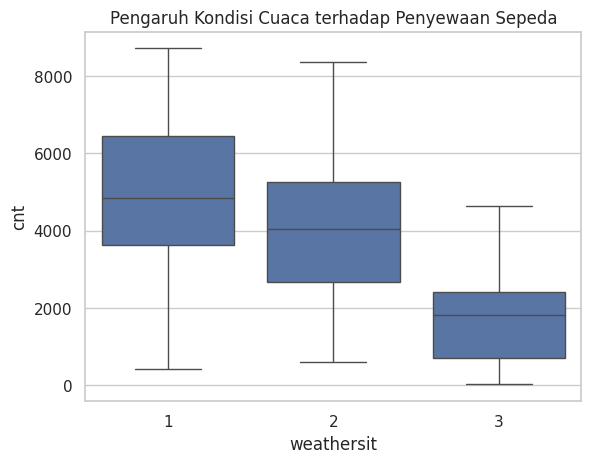

In [28]:
# Kondisi cuaca (kategori) terhadap jumlah penyewaan
print(day_df[['temp','hum','windspeed','cnt']].corr())
plt.figure()
sns.boxplot(x='weathersit', y='cnt', data=day_df)
plt.title('Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda')
plt.show()

* temp → cnt = 0.627 =  Suhu memiliki hubungan positif yang cukup kuat dengan jumlah penyewaan -> Makin hangat suhu makin banyak orang nyewa sepeda.
* hum → cnt = -0.10 = Kelembapan memiliki hubungan negatif yang sangat lemah terhadap penyewaan -> Angin kencang = pengaruhnya tidak terlalu signifikan.
* windspeed → cnt = -0.23 = Kecepatan angin memiliki hubungan negatif terhadap penyewaan -> Angin Kencang = jumlah penyewaan cenderung menurun.
* weathersit = 1 (cuaca cerah) = Median paling tinggi (~5000an) = Sebaran juga tinggi --> kondisi paling ideal buat nyewa sepeda.

### Pertanyaan 2:
2.   Pada jam berapa dan hari apa jumlah penyewaan sepeda paling tinggi?


---. Rata-rata penyewaan sepeda per jam: ---
hr
0      53.898072
1      33.375691
2      22.869930
3      11.727403
4       6.352941
5      19.889819
6      76.044138
7     212.064649
8     359.011004
9     219.309491
10    173.668501
11    208.143054
12    253.315934
13    253.661180
14    240.949246
15    251.233196
16    311.983562
17    461.452055
18    425.510989
19    311.523352
20    226.030220
21    172.314560
22    131.335165
23     87.831044
Name: cnt, dtype: float64


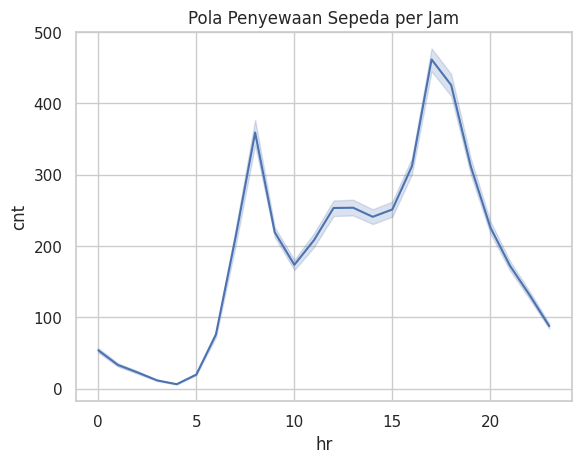


---. Rata-rata penyewaan sepeda per hari: ---
weekday
0    177.468825
1    183.744655
2    191.238891
3    191.130505
4    196.436665
5    196.135907
6    190.209793
Name: cnt, dtype: float64


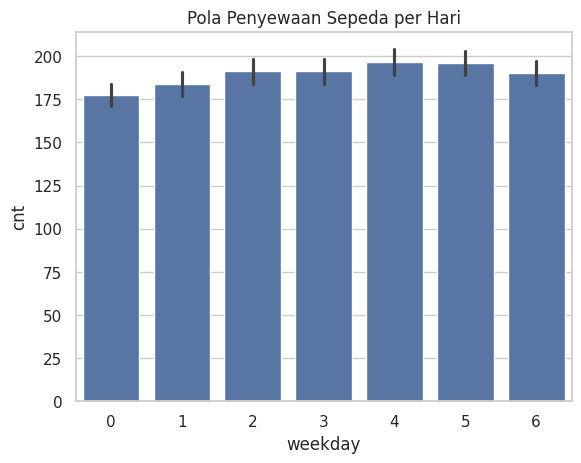

In [29]:
print("\n---. Rata-rata penyewaan sepeda per jam: ---") # Menghitung rata-rata penyewaan sepeda per jam
avg_hour = hour_df.groupby('hr')['cnt'].mean()
print(avg_hour)

plt.figure()
sns.lineplot(x='hr', y='cnt', data=hour_df)
plt.title('Pola Penyewaan Sepeda per Jam')
plt.show()

print("\n---. Rata-rata penyewaan sepeda per hari: ---") # Menghitung rata-rata penyewaan sepeda per hari
avg_day = hour_df.groupby('weekday')['cnt'].mean()
print(avg_day)

plt.figure()
sns.barplot(x='weekday', y='cnt', data=hour_df)
plt.title('Pola Penyewaan Sepeda per Hari')
plt.show()

**Insight:**


1.  Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?  
    * Kondisi cuaca berpengaruh terhadap jumlah penyewaan sepeda. Pada cuaca cerah (weathersit 1), jumlah penyewaan paling tinggi. Saat cuaca berubah menjadi berkabut atau mendung (weathersit 2), jumlah penyewaan mulai menurun. Sedangkan pada kondisi cuaca yang lebih buruk seperti hujan ringan (weathersit 3), jumlah penyewaan menurun cukup signifikan. Hal ini menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah minat pengguna untuk menyewa sepeda.

2.  Pada jam berapa dan hari apa jumlah penyewaan sepeda paling tinggi?
    * Jumlah penyewaan sepeda paling tinggi terjadi pada pagi hari sekitar pukul 07.00–08.00 dan mencapai puncak tertinggi pada sore hari sekitar pukul 17.00–18.00.
    * Penyewaan sepeda relatif stabil tiap hari, tapi mulai meningkat di hari Jumat dan Sabtu. Menariknya, jumlah penyewaan di dua hari ini justru lebih tinggi dibanding hari Minggu.


## Analisis Lanjutan (Opsional)

## Conclusion

1.  Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?  
    * Kondisi cuaca berpengaruh terhadap jumlah penyewaan sepeda. Cuaca cerah menghasilkan jumlah penyewaan tertinggi, sedangkan semakin buruk kondisi cuaca, jumlah penyewaan cenderung menurun.

2.  Pada jam berapa dan hari apa jumlah penyewaan sepeda paling tinggi?
    * Penyewaan sepeda paling tinggi terjadi pada pagi hari sekitar pukul 07.00–08.00 dan sore hari sekitar pukul 17.00–18.00. Untuk hari, jumlah penyewaan relatif stabil, namun sedikit lebih tinggi pada pertengahan hingga akhir minggu.

In [30]:
# Menggabungkan data berdasarkan tanggal
all_data = pd.merge(hour_df, day_df, on='dteday', how='inner')

# Simpan ke file CSV
all_data.to_csv('all_data.csv', index=False)
print("File all_data.csv berhasil dibuat")
files.download('all_data.csv')

File all_data.csv berhasil dibuat


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>